# Analysis of the "Development Tools" category

## Libraries and data set loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils as u

In [2]:
df_dt = pd.read_parquet('datos/collabtools.parquet')
df_respondents = pd.read_parquet('datos/respondents.parquet')
df_dt_metrics = pd.read_parquet('datos/collab_tools_metrics.parquet')

In [3]:
df_dt.head(2)

,ResponseId,Collab Tools,Relation
0,2,PyCharm,HaveWorkedWith
1,2,Visual Studio Code,HaveWorkedWith


In [4]:
df_respondents.head(2)

,ResponseId,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,TechEndorse,YearsCode,YearsCodePro,Country,EdLevel_Group,Age_Group,RemoteWork_Clean
0,1,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,USA,No Formal Degree,Under 18,Remote
1,2,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,None,20.0,17.0,GBR,Undergraduate Degree,35-44,Remote


In [5]:
df_dt_metrics.head(2)

Relation,Admired,HaveWorkedWith,WantToWorkWith,PreferenceRate,AdmiredRate
Collab Tools,,,,,
Android Studio,4672,9379,6132,0.65,0.5
BBEdit,302,506,366,0.72,0.6


In [6]:
df_dt_metrics.head(1)

Relation,Admired,HaveWorkedWith,WantToWorkWith,PreferenceRate,AdmiredRate
Collab Tools,,,,,
Android Studio,4672,9379,6132,0.65,0.5


## Top Development Tools

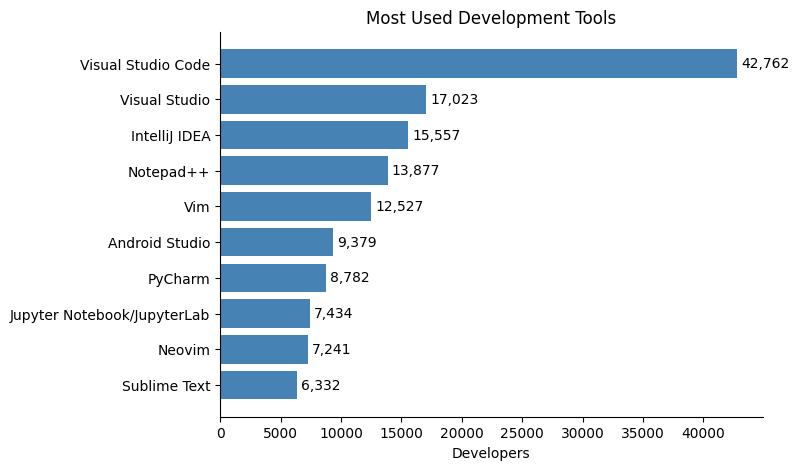

In [7]:
ax_dt_have = u.bars_plot(df_dt_metrics, 'HaveWorkedWith', 'Collab Tools', 'Most Used Development Tools')
plt.show()

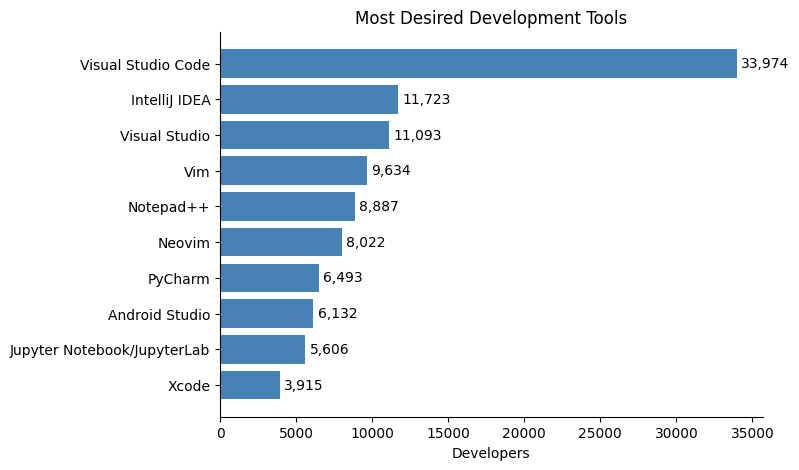

In [8]:
ax_dt_want = u.bars_plot(df_dt_metrics, 'WantToWorkWith', 'Collab Tools', 'Most Desired Development Tools')
plt.show()

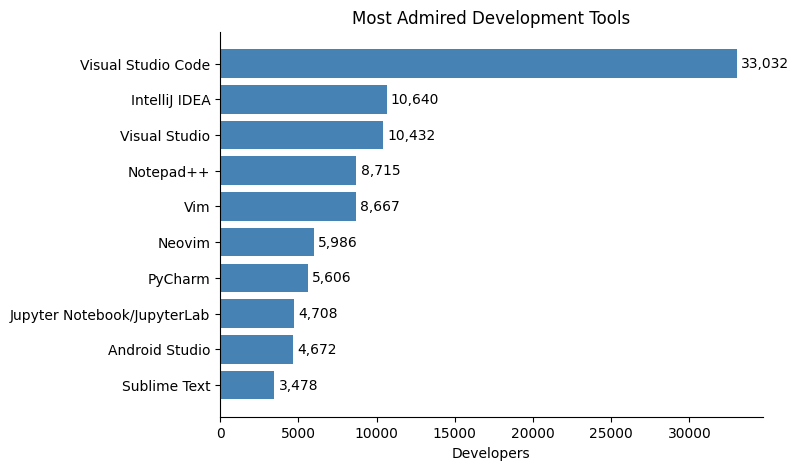

In [9]:
ax_dt_adm = u.bars_plot(df_dt_metrics, 'Admired', 'Collab Tools', 'Most Admired Development Tools')
plt.show()

- Visual Studio Code, Visual Studio e Intellij IDEA son las herramientas de desarrollo mas usadas, admiradas y con mas interes futuro, esto sugiere una alta alineación entre adopción del mercado y preferencia de los desarrolladores.
- Mientras visual Studio Code se mantiene en el top 1, Intellij IDEA pasa a ser el top 2 en admiracion e interes futuro y Visual Studio al top 3.

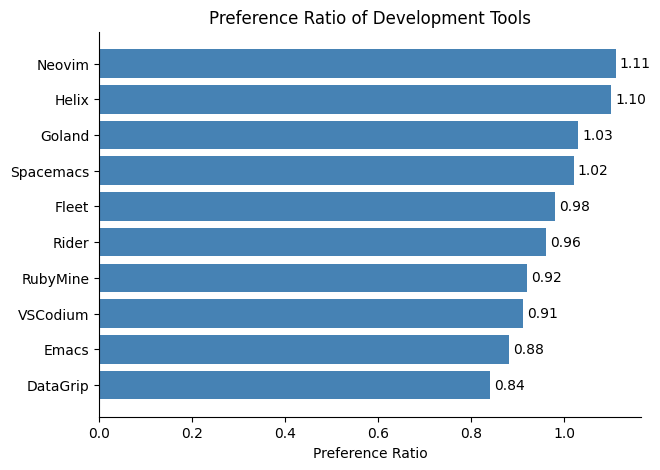

In [10]:
ax_prefer_ratio = u.bars_plot(df_dt_metrics, 'PreferenceRate', 'Collab Tools', 'Preference Ratio of Development Tools', fmt = '{:.2f}', xlabel='Preference Ratio')
plt.show()

Neovim, Helix, Goland y Spacemacs tienen un indice de preferencia mayor a 1, indicando alta alineacion entre uso actual e interes futuro.

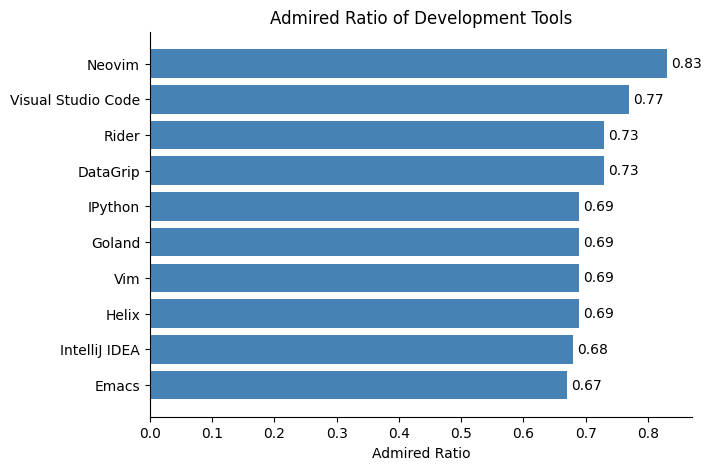

In [11]:
ax_adm_ratio = u.bars_plot(df_dt_metrics, 'AdmiredRate', 'Collab Tools', 'Admired Ratio of Development Tools', fmt = '{:.2f}', xlabel='Admired Ratio')
plt.show()

- Neovim presenta la mayor tasa de admiración (0.83), lo que indica una fuerte alineación entre uso y admiración. Esto sugiere un alto nivel de satisfacción entre los desarrolladores que utilizan esta
- Visual Studio Code, Rider y DataGrip también muestran índices de admiración elevados (0.77, 0.73 y 0.73 respectivamente), lo que refleja una percepción positiva y altos niveles de satisfacción entre los desarrolladores que trabajan con estas herramientas.

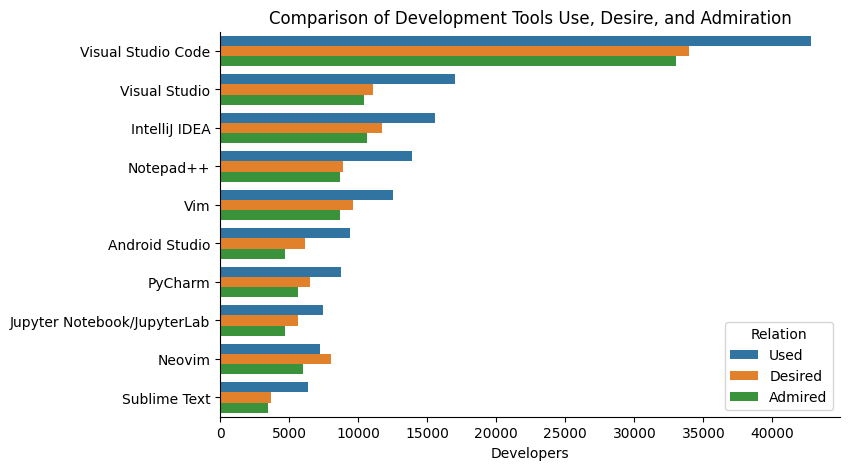

In [12]:
ax_comp = u.bar_comparative_plot(df_dt_metrics, 'Collab Tools', 'Comparison of Development Tools Use, Desire, and Admiration')
plt.show()

- Visual Studio Code es la herramienta mas usada en el mercado del ultimo año, tambien presenta alto interes y admiracion, posicionandose como la herramienta lider.
- 

In [13]:
x_median = df_dt_metrics['HaveWorkedWith'].median()
df_plot = u.assign_quadrant(
    df_dt_metrics, 
    'HaveWorkedWith', 
    'PreferenceRate', 
    x_median, 
    1, 
    'MarketQuadrant',
    'Growth',
    'Emerging',
    'Declining',
    'Mature'
)

growth   = df_plot[df_plot['MarketQuadrant'] == 'Growth'].nlargest(4, 'HaveWorkedWith')
emerging  = df_plot[df_plot['MarketQuadrant'] == 'Emerging'].nlargest(4, 'PreferenceRate')
mature    = df_plot[df_plot['MarketQuadrant'] == 'Mature'].nlargest(4, 'HaveWorkedWith')
declining = df_plot[df_plot['MarketQuadrant'] == 'Declining'].nsmallest(4, 'PreferenceRate')

label_df = pd.concat([growth, emerging, mature, declining])

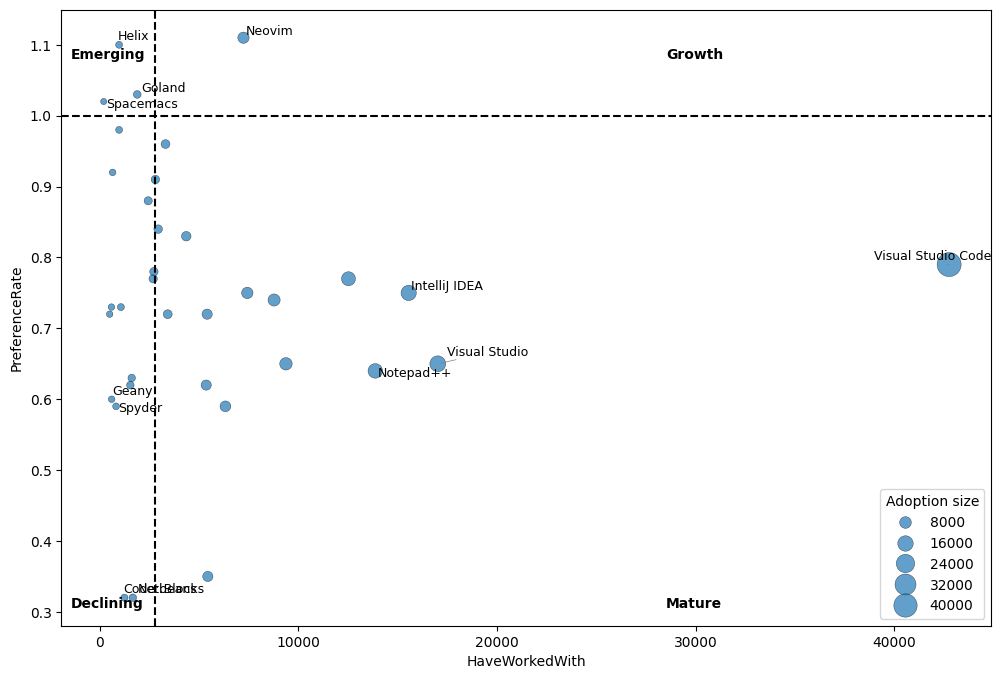

In [14]:
ax_have_prefer = u.quadrant_chart(df_dt_metrics, 'HaveWorkedWith', 'PreferenceRate', x_median, 1, label_df, 'Growth', 'Emerging', 'Declining', 'Mature')
plt.show()

In [15]:
x_median = df_plot['PreferenceRate'].median()
y_median = df_plot['AdmiredRate'].median()

df_plot = u.assign_quadrant(
    df_plot,
    'PreferenceRate',
    'AdmiredRate',
    x_median,
    y_median,
    'PerceptionQuadrant',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

leaders = df_plot[df_plot['PerceptionQuadrant'] =='Leaders'].nlargest(4, 'AdmiredRate')
loved   = df_plot[df_plot['PerceptionQuadrant'] == 'Loved Niche'].nlargest(4, 'AdmiredRate')
trendy  = df_plot[df_plot['PerceptionQuadrant'] == 'Trendy'].nlargest(4, 'PreferenceRate')
weak    = df_plot[df_plot['PerceptionQuadrant'] == 'Weak'].nsmallest(4, 'AdmiredRate')

label_df = pd.concat([leaders, loved, trendy, weak])

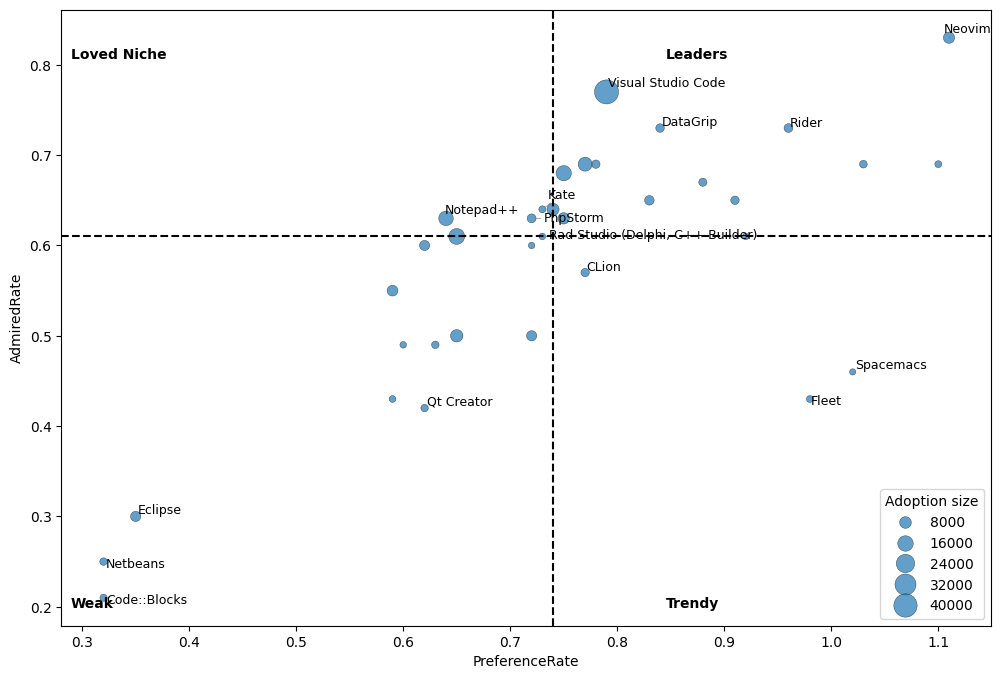

In [16]:
ax_prefer_adm = u.quadrant_chart(
    df_plot,
    'PreferenceRate',
    'AdmiredRate',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

In [17]:
comparison = (
    df_plot[
        ['MarketQuadrant', 'PerceptionQuadrant']
    ]
    .reset_index()
    .sort_values(['MarketQuadrant', 'PerceptionQuadrant'])
)

crosstab = pd.crosstab(
    df_plot['MarketQuadrant'],
    df_plot['PerceptionQuadrant']
)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_pct

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
MarketQuadrant,,,,
Declining,0.214286,0.142857,0.142857,0.500000
Emerging,0.666667,0.000000,0.333333,0.000000
Growth,1.000000,0.000000,0.000000,0.000000
Mature,0.529412,0.176471,0.000000,0.294118


- Todas las plataformas clasificadas en el cuadrante de crecimiento también son percibidas como líderes, lo que sugiere una fuerte alineación entre expansión en el mercado y percepción positiva entre los desarrolladores.
- La mayoría de las plataformas emergentes son percibidas como líderes (67%), mientras que el resto se posiciona como tendencias emergentes (33%). Esto sugiere que muchas tecnologías nuevas ya cuentan con una percepción positiva entre los desarrolladores.
- Las plataformas maduras presentan percepciones más diversas: aunque más de la mitad siguen siendo consideradas líderes, una proporción relevante aparece como tecnologías de nicho apreciadas o incluso con percepción débil.
- Las plataformas en declive muestran la mayor proporción de percepción débil (50%), lo que sugiere que la pérdida de relevancia en el mercado suele acompañarse de una menor valoración por parte de los desarrolladores.

In [18]:
market_score = {
    'Growth': 3,
    'Emerging': 2,
    'Mature': 1,
    'Declining': 0
}

perception_score = {
    'Leaders': 3,
    'Loved Niche': 2,
    'Trendy': 1,
    'Weak': 0
}

df_plot['MarketScore'] = df_plot['MarketQuadrant'].map(market_score)
df_plot['PerceptionScore'] = df_plot['PerceptionQuadrant'].map(perception_score)

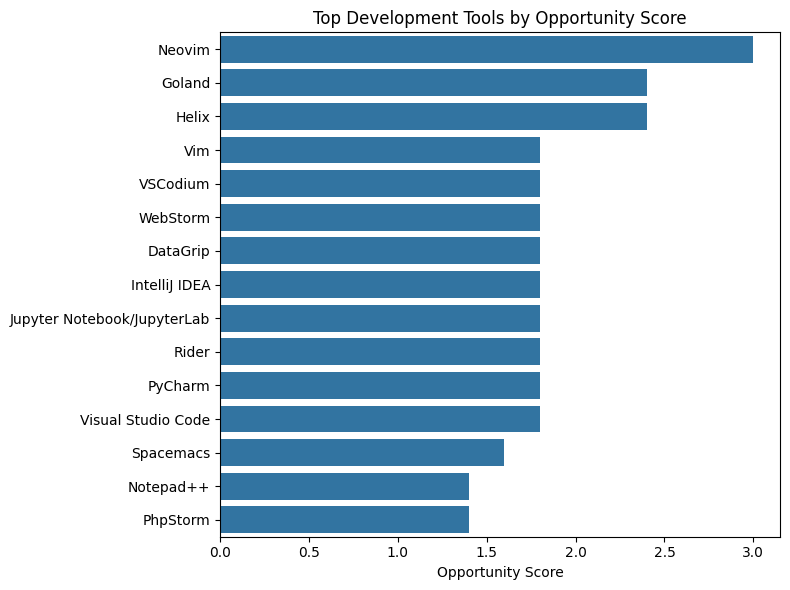

In [19]:
df_plot['OpportunityScore'] = (
    df_plot['MarketScore'] * 0.6 +
    df_plot['PerceptionScore'] * 0.4
)

ranking = (
    df_plot
    .sort_values('OpportunityScore', ascending=False).reset_index()
    [['Collab Tools', 'MarketQuadrant', 'PerceptionQuadrant', 'OpportunityScore']]
)

top = 15

df_rank = (
    df_plot
    .sort_values('OpportunityScore', ascending=False)
    .head(top)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_rank,
    x='OpportunityScore',
    y='Collab Tools'
)

plt.title('Top Development Tools by Opportunity Score')
plt.xlabel('Opportunity Score')
plt.ylabel('')

plt.tight_layout()
plt.show()

- Neovim presenta el mayor Opportunity Score (3.0), lo que indica que el interés por trabajar con esta herramienta es considerablemente mayor que su uso actual. Esto sugiere un alto potencial de crecimiento y adopción futura entre los desarrolladores.
- Goland y Helix muestran también niveles elevados de oportunidad (2.4), lo que sugiere que existe un interés significativo por parte de los desarrolladores que aún no se refleja completamente en su nivel de adopción.
- Varias herramientas ampliamente utilizadas como Visual Studio Code, IntelliJ IDEA y PyCharm presentan un Opportunity Score cercano a 1.8, lo que indica que, a pesar de su adopción consolidada, continúan generando interés entre desarrolladores que aún no las utilizan.

Las herramientas con mayor Opportunity Score tienden a ser tecnologías con comunidades entusiastas pero menor adopción general, como Neovim o Helix. En contraste, herramientas ampliamente consolidadas como Visual Studio Code o IntelliJ IDEA muestran oportunidades de crecimiento más moderadas, ya que gran parte de los desarrolladores interesados ya las utilizan.

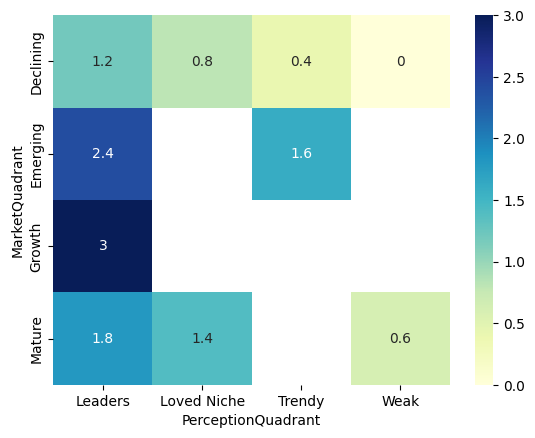

In [20]:
pivot = (
    df_plot
    .pivot_table(
        values = 'OpportunityScore',
        index = 'MarketQuadrant',
        columns = 'PerceptionQuadrant'
    )
)

sns.heatmap(pivot, annot = True, cmap = 'YlGnBu')
plt.show()

In [21]:
df_plot['AlignmentGap'] = (
    df_plot['PerceptionScore'] - df_plot['MarketScore']
)

df_plot.sort_values('AlignmentGap', ascending=False)['AlignmentGap'].head(5)

Collab Tools
RubyMine    3
IPython     3
Emacs       3
Vim         2
VSCodium    2
Name: AlignmentGap, dtype: int64

RubyMine, IPython y Emacs presentan una alineacion elevada, superior a su posición en el mercado, lo que indica posibles oportunidades de crecimiento impulsadas por entusiasmo y admiración de la comunidad.

In [22]:
df_plot.sort_values('AlignmentGap')['AlignmentGap'].head(5)

Collab Tools
Android Studio   -1
Eclipse          -1
Nano             -1
Sublime Text     -1
Spacemacs        -1
Name: AlignmentGap, dtype: int64

Android Studio y Eclipse presentan una alineación negativa, indicando menos oportunidades de crecimiento dentro del ecosistema.

In [23]:
df_dt_exp = (
    df_dt
    .merge(df_respondents[['ResponseId', 'YearsCodePro', 'Age_Group', 'RemoteWork_Clean', 'EdLevel_Group', 'Country']], on = 'ResponseId')
)
df_dt_exp.head()

,ResponseId,Collab Tools,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country
0,2,PyCharm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
1,2,Visual Studio Code,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
2,2,WebStorm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
3,3,Visual Studio,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR
4,5,Vim,HaveWorkedWith,NaN,18-24,No especificado,No Formal Degree,NOR


In [24]:
df_analysis = df_dt_exp.merge(
    df_plot.reset_index()[['Collab Tools', 'MarketQuadrant', 'PerceptionQuadrant', 
             'MarketScore', 'PerceptionScore', 'OpportunityScore', 'AlignmentGap']],
    on = 'Collab Tools',
    how = 'left'
)
df_analysis.head()

,ResponseId,Collab Tools,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country,MarketQuadrant,PerceptionQuadrant,MarketScore,PerceptionScore,OpportunityScore,AlignmentGap
0,2,PyCharm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
1,2,Visual Studio Code,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
2,2,WebStorm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
3,3,Visual Studio,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
4,5,Vim,HaveWorkedWith,NaN,18-24,No especificado,No Formal Degree,NOR,Mature,Leaders,1,3,1.8,2


In [25]:
df_analysis['MarketQuadrant'].isna().sum()

np.int64(0)

In [26]:
df_plot.reset_index()['Collab Tools'].nunique() == len(df_plot)

True

In [27]:
len(df_dt_exp) == len(df_analysis)

True

In [28]:
(
    df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']
    .groupby('MarketQuadrant')['YearsCodePro']
    .mean()
    .sort_values()
)

MarketQuadrant
Growth        7.806060
Emerging      9.657944
Mature        9.977344
Declining    10.576240
Name: YearsCodePro, dtype: float64

Se observa que las herramientras en crecimiento (Growth) tienen el menor promedio de experiencia profesional, por otro lado, las herramientas emergentes, maduras y en declive presentan promedio de experiencia profesional cercanad (9-11 años), lo que sugiere cierta influencia de los niveles de experiencia en las percepciones y adopciones de herramientas.

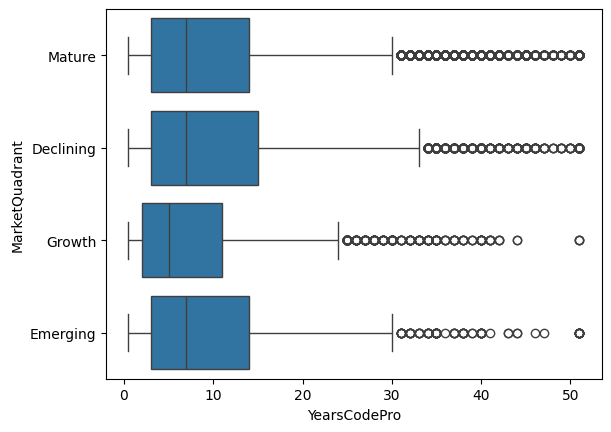

In [29]:
sns.boxplot(
    data=df_analysis[df_analysis['Relation'] == 'HaveWorkedWith'],
    x = 'YearsCodePro',
    y = 'MarketQuadrant'
)
plt.show()

En general, la distribución de años de experiencia profesional es similar entre los distintos cuadrantes del mercado (Mature, Emerging y Declining). Las medianas y rangos intercuartílicos presentan valores cercanos, lo que sugiere que el nivel de experiencia de los desarrolladores no varía significativamente según la posición de las plataformas en el mercado. Además, en todos los cuadrantes se observan outliers con alta experiencia, indicando la presencia de profesionales muy experimentados en cada categoría.

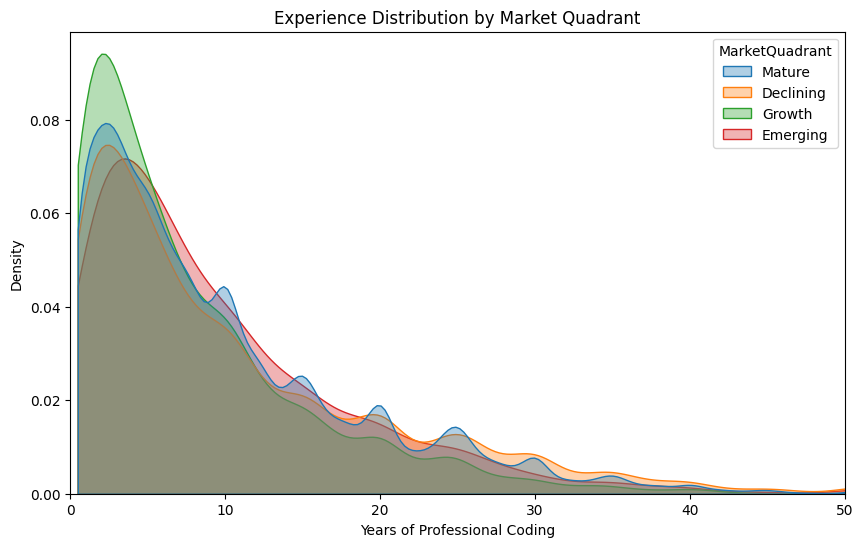

In [30]:
df_plot2 = df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_plot2,
    x = 'YearsCodePro',
    hue = 'MarketQuadrant',
    common_norm = False,
    fill = True,
    alpha = 0.35,
    cut = 0
)
plt.xlim(0,50)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Density')
plt.title('Experience Distribution by Market Quadrant')
plt.show()

In [31]:
pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
Age_Group,,,,
18-24,0.654025,0.142777,0.031836,0.171362
25-34,0.653682,0.159222,0.017129,0.169968
35-44,0.619739,0.195751,0.012805,0.171705
45-54,0.574453,0.226585,0.014389,0.184573
55-64,0.519187,0.262071,0.013379,0.205363
65+,0.470491,0.280635,0.009007,0.239867
Under 18,0.639433,0.148799,0.031485,0.180284
Unknown,0.568868,0.188940,0.013313,0.228879


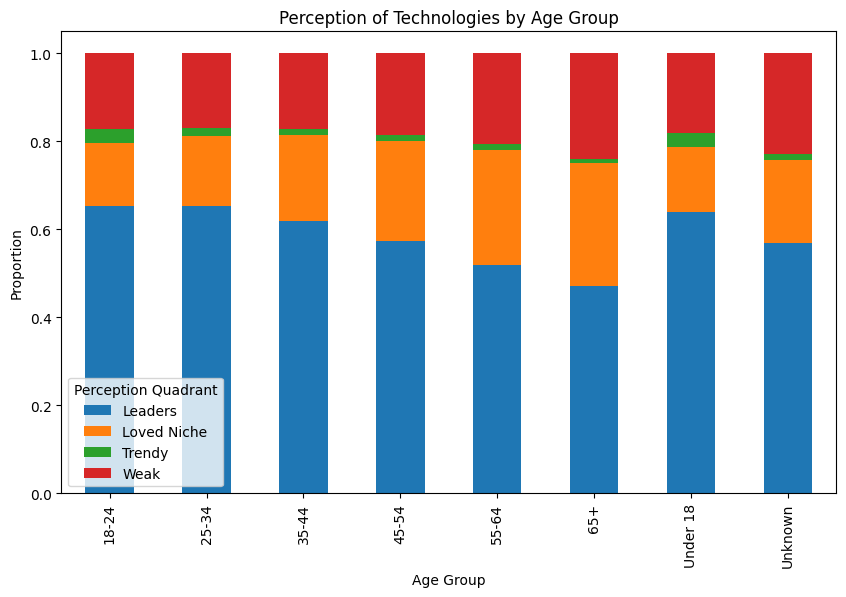

In [32]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Perception of Technologies by Age Group')
plt.legend(title = 'Perception Quadrant')
plt.show()

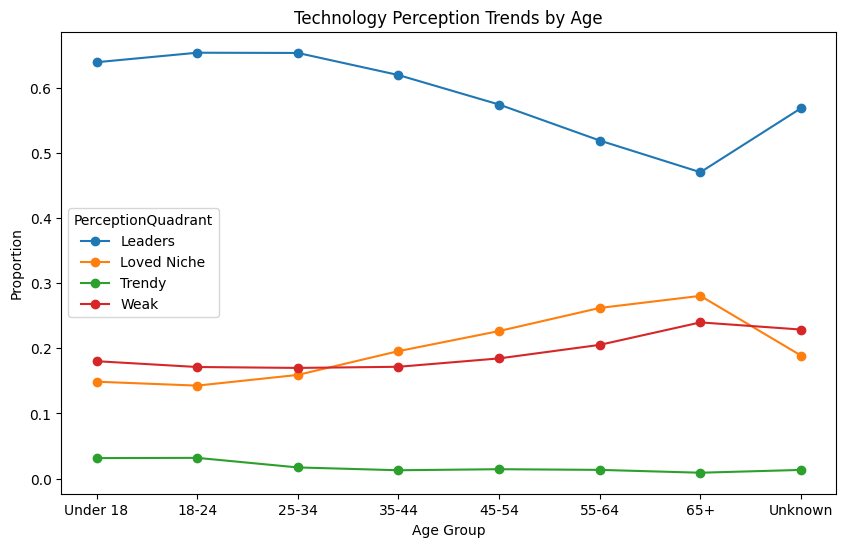

In [33]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

ct.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Technology Perception Trends by Age')
plt.show()

- La percepción de tecnologías líderes predomina en todos los grupos de edad, alcanzando sus niveles más altos entre los desarrolladores de 18 a 34 años.
- A medida que aumenta la edad, crece la proporción de tecnologías percibidas como nicho o en declive, lo que podría reflejar una mayor permanencia o especialización en herramientas específicas.
- Las tecnologías clasificadas como trendy presentan la menor proporción en todos los grupos de edad, lo que sugiere que relativamente pocas herramientas son percibidas principalmente como tendencias emergentes.